In [1]:
import json
from pathlib import Path

# path to the JSON file
p = Path('disputes-training.json')

# If `data` is not defined (or you prefer to load from the file), this will load it.
try:
    data
except NameError:
    data = json.loads(p.read_text())

# Produce three useful extracted shapes:
# - lists: list of dicts {domain: <domain>, typos: [<typo1>, <typo2>, ...]}
# - flattened_lists: list of dicts {domain: <domain>, typo: <typo>, count: <count>}
# - stacked: dict mapping domain -> list of (typo, count) tuples
lists = []
flattened_lists = []
stacked = {}

for domain, typos in data.items():
    typo_names = list(typos.keys())
    lists.append({'domain': domain, 'typos': typo_names})
    stacked[domain] = list(typos.items())
    for typo, count in typos.items():
        flattened_lists.append({'domain': domain, 'typo': typo, 'count': count})

# Replace existing notebook variables (if any) with the extracted results
# so they can be used by later cells.
globals().update({
    'lists': lists,
    'flattened_lists': flattened_lists,
    'stacked': stacked,
})

# Quick summary
print(lists)


[{'domain': 'microsoft.com', 'typos': ['moicrosoft.com', 'microsof.com', 'microsorft.com', 'microswoft.com', 'microspft.com', 'micrisoft.com', 'wwwmicrosoft.com', 'microsofr.com', 'micrtosoft.com', 'microesoft.com', 'micerosoft.com']}, {'domain': 'libertymutual.com', 'typos': ['libetrymutual.com', 'ilbertymutual.com', 'libertymutua.com', 'libertymuual.com', 'libertyutual.com', 'libertymutusl.com', 'libertymutuel.com', 'libertymutal.com', 'libertymuutal.com', 'libertymurual.com', 'libertymtual.com', 'libertymutul.com', 'libertymitual.com', 'libertymutula.com', 'ibertymutual.com', 'libertymutuao.com', 'linertymutual.com', 'libretymutual.com', 'wwwlibertymutual.com', 'lkbertymutual.com', 'libertymutyal.com']}, {'domain': 'advanceautoparts.com', 'typos': ['dvanceautoparts.com', 'wwwadvanceautoparts.com', 'advanecautoparts.com', 'advanceautopart.com', 'advanceautoparst.com', 'advanceautpparts.com', 'advanceauroparts.com', 'advanceauoparts.com', 'advancesutoparts.com', 'advancedautoparts.com

In [2]:
#Now take the list and per domain count the typos
typo_counts = {entry['domain']: len(entry['typos']) for entry in lists}
print(typo_counts)



{'microsoft.com': 11, 'libertymutual.com': 21, 'advanceautoparts.com': 39, 'allstate.com': 23, 'centerpointenergy.com': 54, 'oracle.com': 11, 'thehartford.com': 10, 'alaskaair.com': 18, 'wellsfargo.com': 48, 'citizensbank.com': 27, 'americanexpress.com': 7, 'modernatx.com': 8, 'verizon.com': 9, 'wayfair.com': 5, 'bankofamerica.com': 38, 'capitalone.com': 14, 'pfizer.com': 7, 'target.com': 42, 'halliburton.com': 8, 'google.com': 34, 'homedepot.com': 80, 'dominionenergy.com': 20, 'corning.com': 8, 'kohls.com': 30, 'tractorsupply.com': 7, 'netflix.com': 7, 'guardianlife.com': 5}


In [3]:
#in data there is a value for each typo, average them per domain
average_typos = {
    domain: sum(count for count in typos.values()) / len(typos)
    for domain, typos in data.items()
}
print(average_typos)

{'microsoft.com': 1.0909090909090908, 'libertymutual.com': 1.0476190476190477, 'advanceautoparts.com': 1.1282051282051282, 'allstate.com': 1.0, 'centerpointenergy.com': 1.1851851851851851, 'oracle.com': 1.0909090909090908, 'thehartford.com': 1.2, 'alaskaair.com': 1.2222222222222223, 'wellsfargo.com': 1.125, 'citizensbank.com': 1.0740740740740742, 'americanexpress.com': 1.4285714285714286, 'modernatx.com': 1.5, 'verizon.com': 1.1111111111111112, 'wayfair.com': 1.0, 'bankofamerica.com': 1.5, 'capitalone.com': 1.3571428571428572, 'pfizer.com': 1.2857142857142858, 'target.com': 1.0476190476190477, 'halliburton.com': 1.375, 'google.com': 1.0588235294117647, 'homedepot.com': 1.1125, 'dominionenergy.com': 1.0, 'corning.com': 1.25, 'kohls.com': 1.0666666666666667, 'tractorsupply.com': 1.0, 'netflix.com': 1.5714285714285714, 'guardianlife.com': 1.0}


In [4]:
#in data there is a value for each typo, count how many are 3, then 2 and then 1 per domain
typos_eq3 = [(domain, sum(1 for v in typos.values() if v == 3)) for domain, typos in data.items()]
typos_eq2 = [(domain, sum(1 for v in typos.values() if v == 2)) for domain, typos in data.items()]
typos_eq1 = [(domain, sum(1 for v in typos.values() if v == 1)) for domain, typos in data.items()]

print('typos_eq3:', typos_eq3)
print('typos_eq2:', typos_eq2)
print('typos_eq1:', typos_eq1)


typos_eq3: [('microsoft.com', 0), ('libertymutual.com', 0), ('advanceautoparts.com', 0), ('allstate.com', 0), ('centerpointenergy.com', 1), ('oracle.com', 0), ('thehartford.com', 0), ('alaskaair.com', 0), ('wellsfargo.com', 0), ('citizensbank.com', 0), ('americanexpress.com', 1), ('modernatx.com', 0), ('verizon.com', 0), ('wayfair.com', 0), ('bankofamerica.com', 2), ('capitalone.com', 0), ('pfizer.com', 0), ('target.com', 0), ('halliburton.com', 0), ('google.com', 0), ('homedepot.com', 1), ('dominionenergy.com', 0), ('corning.com', 0), ('kohls.com', 0), ('tractorsupply.com', 0), ('netflix.com', 0), ('guardianlife.com', 0)]
typos_eq2: [('microsoft.com', 1), ('libertymutual.com', 1), ('advanceautoparts.com', 5), ('allstate.com', 0), ('centerpointenergy.com', 8), ('oracle.com', 1), ('thehartford.com', 2), ('alaskaair.com', 4), ('wellsfargo.com', 6), ('citizensbank.com', 2), ('americanexpress.com', 1), ('modernatx.com', 4), ('verizon.com', 1), ('wayfair.com', 0), ('bankofamerica.com', 15),

In [5]:
# Sample JSONL lines shown above describe company records.
# Build a mapping domain -> [market_value, security_analysts_est, assets, popularity, osint_domains, naics_sector]
import json
from pathlib import Path    
# path to the JSON file
p = Path('companies-training.jsonl')
data_company = []
with p.open() as f:
    for line in f:
        data_company.append(json.loads(line))
company_info = {}
for entry in data_company:
    domain = entry['domain']
    company_info[domain] = {
        'market_value': entry['market_value'],
        'security_analysts_est': entry['security_analysts_est'],
        'assets': entry['assets'],
        'popularity': entry['popularity'],
        'osint_domains': entry['osint_domains'],
        'naics_sector': entry['naics_sector']
    }
print(company_info)


{'advanceautoparts.com': {'market_value': 7208.0, 'security_analysts_est': 2.2086859931, 'assets': 12018.5, 'popularity': 23937, 'osint_domains': 1, 'naics_sector': 'Retail Trade'}, 'alaskaair.com': {'market_value': 5348.0, 'security_analysts_est': 3.8570777919, 'assets': 14186.0, 'popularity': 11264, 'osint_domains': 4, 'naics_sector': 'Transportation and Warehousing'}, 'allstate.com': {'market_value': 26919.0, 'security_analysts_est': 259.3715043295, 'assets': 97957.0, 'popularity': 6297, 'osint_domains': 19, 'naics_sector': 'Finance and Insurance'}, 'americanexpress.com': {'market_value': 130357.0, 'security_analysts_est': 211.7773887106, 'assets': 228354.0, 'popularity': 1261, 'osint_domains': 47, 'naics_sector': 'Finance and Insurance'}, 'bankofamerica.com': {'market_value': 234293.0, 'security_analysts_est': 1303.3497861285, 'assets': 3051375.0, 'popularity': 766, 'osint_domains': 225, 'naics_sector': 'Finance and Insurance'}, 'capitalone.com': {'market_value': 43308.0, 'security

company_info has all the data per company

typos_eq1 has the number of low risk typos domain

typos_eq2 has the number of medium risk typos domain

typos_eq3 has the number of high risk typos domain

average_typos has the avg of the different disputed domains given per domain

typo_counts has the number of disputes per domain 

lists has all the disputes domains per domain 


points: 27


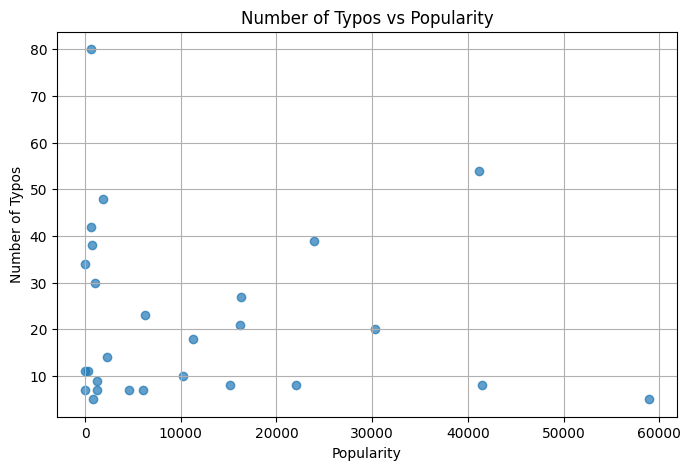

Pearson correlation (popularity, #typos): -0.082


In [6]:
import numpy as np

import matplotlib.pyplot as plt

# build matching lists (use 0 if a domain has no entry in typo_counts)
popularity_list = []
typo_list = []
for domain, info in company_info.items():
    popularity_list.append(info.get('popularity', 0))
    typo_list.append(typo_counts.get(domain, 0))

# quick sanity print
print("points:", len(popularity_list))

# scatter plot (use log x to reduce skew if desired)
plt.figure(figsize=(8,5))
plt.scatter(popularity_list, typo_list, alpha=0.7)
plt.xlabel('Popularity')
plt.ylabel('Number of Typos')
plt.title('Number of Typos vs Popularity')
plt.grid(True)
plt.show()

# Pearson correlation
if len(popularity_list) > 1:
    corr = np.corrcoef(popularity_list, typo_list)[0,1]
    print(f"Pearson correlation (popularity, #typos): {corr:.3f}")


points: 25


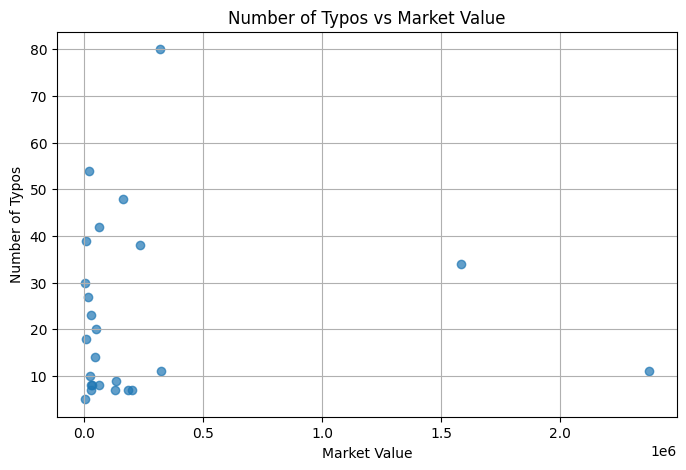

Pearson correlation (market_value, #typos): 0.008


In [7]:
# build matching lists (skip companies with no market_value)
market_list = []
typo_list = []
for domain, info in company_info.items():
    mv = info.get('market_value')
    if mv is None:
        continue
    market_list.append(mv)
    typo_list.append(typo_counts.get(domain, 0))

# quick sanity print
print("points:", len(market_list))

# scatter plot
plt.figure(figsize=(8,5))
plt.scatter(market_list, typo_list, alpha=0.7)
plt.xlabel('Market Value')
plt.ylabel('Number of Typos')
plt.title('Number of Typos vs Market Value')
plt.grid(True)
plt.show()

# Pearson correlation
if len(market_list) > 1:
    corr_market = np.corrcoef(market_list, typo_list)[0,1]
    print(f"Pearson correlation (market_value, #typos): {corr_market:.3f}")


points: 27


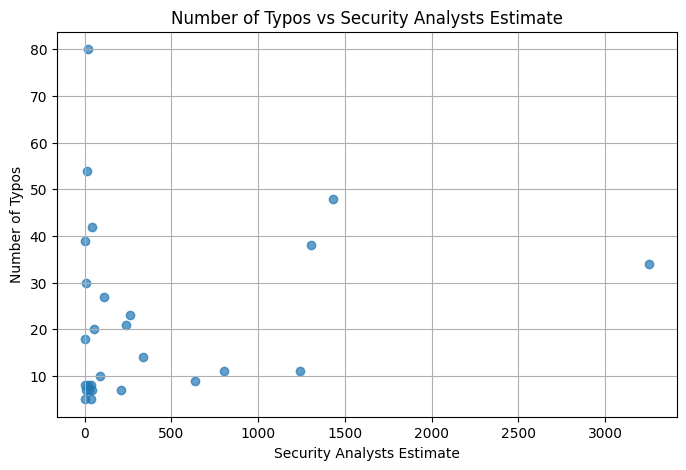

Pearson correlation (security_analysts_est, #typos): 0.176


In [8]:
# build matching lists (skip companies with no security_analysts_est)
analyst_list = []
typo_list = []
for domain, info in company_info.items():
    est = info.get('security_analysts_est')
    if est is None or (isinstance(est, float) and np.isnan(est)):
        continue
    analyst_list.append(est)
    typo_list.append(typo_counts.get(domain, 0))

# quick sanity print
print("points:", len(analyst_list))

# scatter plot
plt.figure(figsize=(8,5))
plt.scatter(analyst_list, typo_list, alpha=0.7)
plt.xlabel('Security Analysts Estimate')
plt.ylabel('Number of Typos')
plt.title('Number of Typos vs Security Analysts Estimate')
plt.grid(True)
plt.show()

# Pearson correlation
if len(analyst_list) > 1:
    corr_security = np.corrcoef(analyst_list, typo_list)[0,1]
    print(f"Pearson correlation (security_analysts_est, #typos): {corr_security:.3f}")

assets points: 27


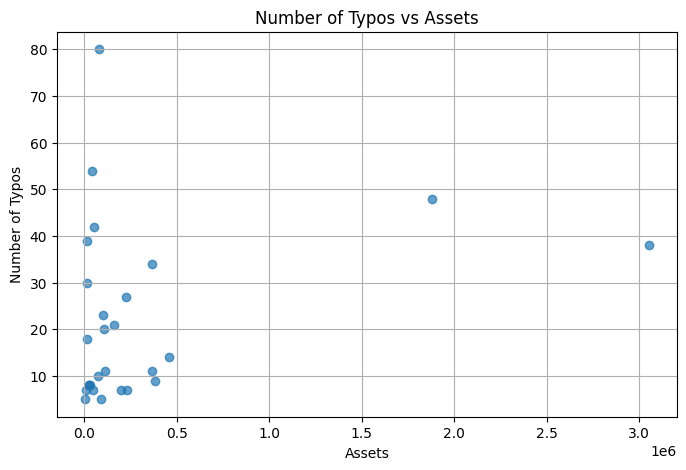

Pearson correlation (assets, #typos): 0.272
osint points: 27


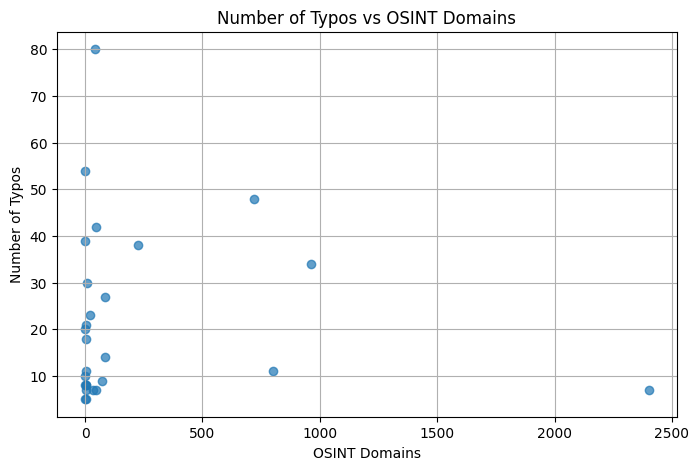

Pearson correlation (osint_domains, #typos): -0.039


In [9]:
# Compare Number of Typos vs Assets and vs OSINT domains

# Assets vs #typos
assets_list = []
typo_list_assets = []
for domain, info in company_info.items():
    assets = info.get('assets')
    if assets is None or (isinstance(assets, float) and np.isnan(assets)):
        continue
    assets_list.append(assets)
    typo_list_assets.append(typo_counts.get(domain, 0))

print("assets points:", len(assets_list))

plt.figure(figsize=(8,5))
plt.scatter(assets_list, typo_list_assets, alpha=0.7)
plt.xlabel('Assets')
plt.ylabel('Number of Typos')
plt.title('Number of Typos vs Assets')
plt.grid(True)
plt.show()

if len(assets_list) > 1:
    corr_assets = np.corrcoef(assets_list, typo_list_assets)[0,1]
    print(f"Pearson correlation (assets, #typos): {corr_assets:.3f}")

# OSINT domains vs #typos
osint_list = []
typo_list_osint = []
for domain, info in company_info.items():
    osint = info.get('osint_domains')
    if osint is None or (isinstance(osint, float) and np.isnan(osint)):
        continue
    osint_list.append(osint)
    typo_list_osint.append(typo_counts.get(domain, 0))

print("osint points:", len(osint_list))

plt.figure(figsize=(8,5))
plt.scatter(osint_list, typo_list_osint, alpha=0.7)
plt.xlabel('OSINT Domains')
plt.ylabel('Number of Typos')
plt.title('Number of Typos vs OSINT Domains')
plt.grid(True)
plt.show()

if len(osint_list) > 1:
    corr_osint = np.corrcoef(osint_list, typo_list_osint)[0,1]
    print(f"Pearson correlation (osint_domains, #typos): {corr_osint:.3f}")

filtered points: 23


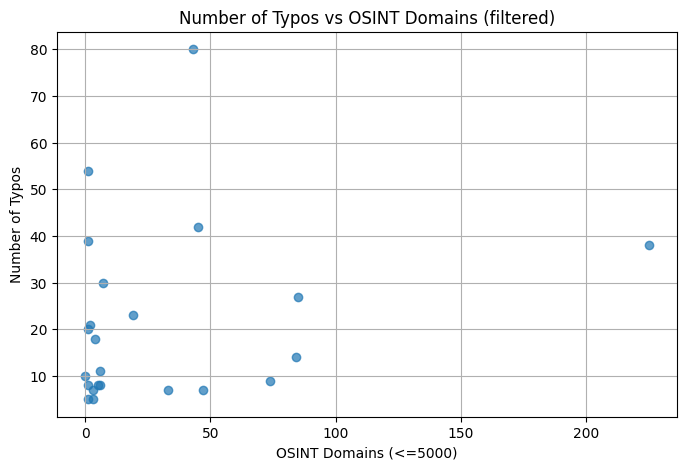

Pearson correlation (osint_domains_filtered, #typos): 0.228


In [10]:
# Redo osint analysis excluding outliers (over 5000) and do the correlation again
osint_list_filtered = []
typo_list_osint_filtered = []
for domain, info in company_info.items():
    osint_domains = info.get('osint_domains', 0) or 0
    if osint_domains > 500:
        continue
    osint_list_filtered.append(osint_domains)
    typo_list_osint_filtered.append(typo_counts.get(domain, 0))

print("filtered points:", len(osint_list_filtered))

plt.figure(figsize=(8,5))
plt.scatter(osint_list_filtered, typo_list_osint_filtered, alpha=0.7)
plt.xlabel('OSINT Domains (<=5000)')
plt.ylabel('Number of Typos')
plt.title('Number of Typos vs OSINT Domains (filtered)')
plt.grid(True)
plt.show()

if len(osint_list_filtered) > 1:
    corr_osint_filtered = np.corrcoef(osint_list_filtered, typo_list_osint_filtered)[0,1]
    print(f"Pearson correlation (osint_domains_filtered, #typos): {corr_osint_filtered:.3f}")
else:
    print("Not enough points to compute correlation.")

filtered points: 25


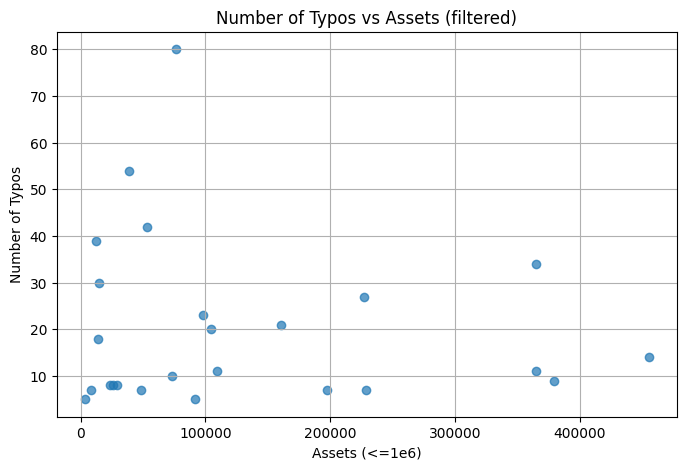

Pearson correlation (assets_filtered, #typos): -0.112


In [11]:
#Redo assets analysis excluding outliers (over 1e12) and do the correlation again
assets_list_filtered = []
typo_list_assets_filtered = []
for domain, info in company_info.items():
    assets = info.get('assets', 0) or 0
    if assets > 1e6:
        continue
    assets_list_filtered.append(assets)
    typo_list_assets_filtered.append(typo_counts.get(domain, 0))

print("filtered points:", len(assets_list_filtered))

plt.figure(figsize=(8,5))
plt.scatter(assets_list_filtered, typo_list_assets_filtered, alpha=0.7)
plt.xlabel('Assets (<=1e6)')
plt.ylabel('Number of Typos')
plt.title('Number of Typos vs Assets (filtered)')
plt.grid(True)
plt.show()

if len(assets_list_filtered) > 1:
    corr_assets_filtered = np.corrcoef(assets_list_filtered, typo_list_assets_filtered)[0,1]
    print(f"Pearson correlation (assets_filtered, #typos): {corr_assets_filtered:.3f}")
else:
    print("Not enough points to compute correlation.")

In [12]:
#print the domain with the highest number of typos
max_typos_domain = max(typo_counts, key=typo_counts.get)
print(f"Domain with the highest number of typos: {max_typos_domain}")
#print the domain with the highest average number of typos
max_avg_typos_domain = max(average_typos, key=average_typos.get)
print(f"Domain with the highest average number of typos: {max_avg_typos_domain}")
#print the most popular domain
most_popular_domain = max(company_info, key=lambda d: company_info[d].get('popularity', 0))
print(f"Most popular domain: {most_popular_domain}")

#Print the popularity of these two domains

print(f"Popularity of {max_typos_domain}: {company_info.get(max_typos_domain, {}).get('popularity', 'N/A')}")
print(f"Popularity of {max_avg_typos_domain}: {company_info.get(max_avg_typos_domain, {}).get('popularity', 'N/A')}")

#print the ordered popularity of all domains
ordered_popularity = sorted(
    ((domain, info.get('popularity', 0)) for domain, info in company_info.items()),
    key=lambda x: x[1],
    reverse=True
)
print("Ordered popularity of all domains:")
for domain, popularity in ordered_popularity:
    print(f"{domain}: {popularity}")

Domain with the highest number of typos: homedepot.com
Domain with the highest average number of typos: netflix.com
Most popular domain: guardianlife.com
Popularity of homedepot.com: 594
Popularity of netflix.com: 22
Ordered popularity of all domains:
guardianlife.com: 58891
halliburton.com: 41504
centerpointenergy.com: 41197
dominionenergy.com: 30262
advanceautoparts.com: 23937
modernatx.com: 22054
citizensbank.com: 16241
libertymutual.com: 16166
corning.com: 15185
alaskaair.com: 11264
thehartford.com: 10279
allstate.com: 6297
pfizer.com: 6079
tractorsupply.com: 4617
capitalone.com: 2326
wellsfargo.com: 1832
verizon.com: 1267
americanexpress.com: 1261
kohls.com: 1013
wayfair.com: 828
bankofamerica.com: 766
target.com: 616
homedepot.com: 594
oracle.com: 288
netflix.com: 22
microsoft.com: 4
google.com: 1



Metric: popularity — points: 27


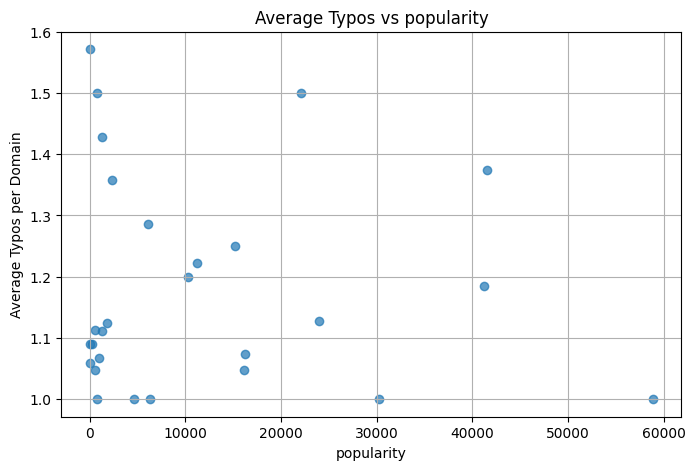

Pearson correlation (avg_typos, popularity): -0.066

Metric: market_value — points: 25


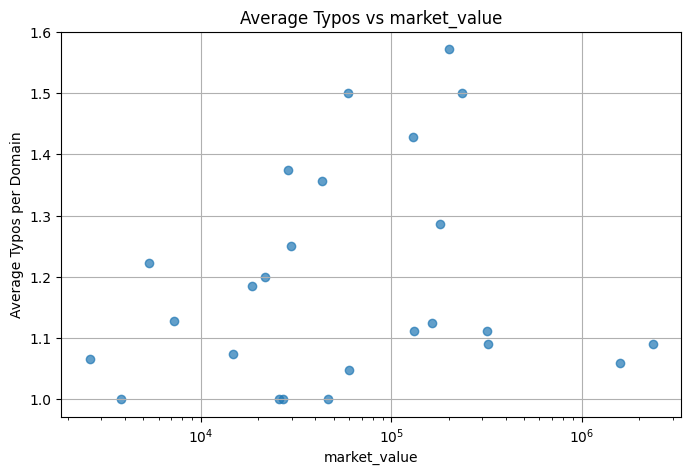

Pearson correlation (avg_typos, market_value): -0.145

Metric: security_analysts_est — points: 27


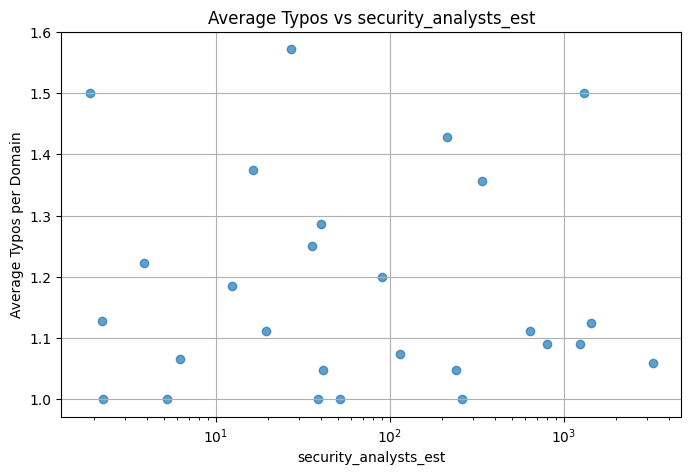

Pearson correlation (avg_typos, security_analysts_est): -0.078

Metric: assets — points: 27


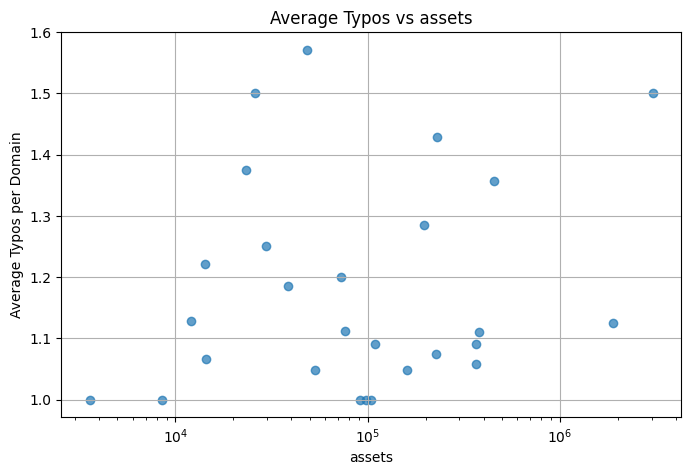

Pearson correlation (avg_typos, assets): 0.288

Metric: osint_domains — points: 27


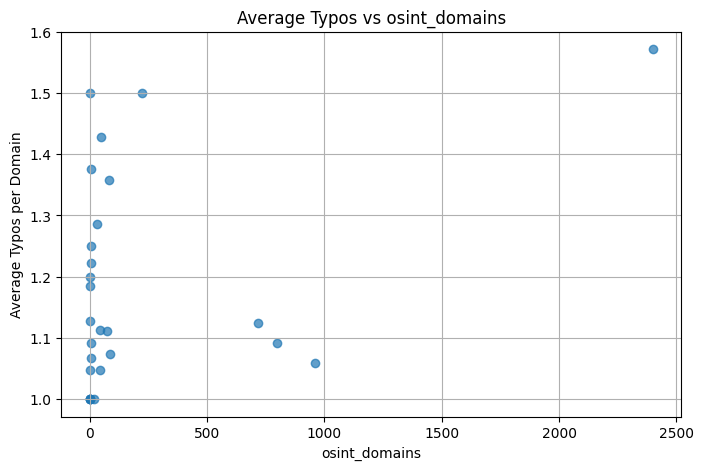

Pearson correlation (avg_typos, osint_domains): 0.347


In [13]:
# compare average typos per domain (average_typos) vs various company_info metrics
metrics = ['popularity', 'market_value', 'security_analysts_est', 'assets', 'osint_domains']

for metric in metrics:
    x = []
    y = []
    for domain, info in company_info.items():
        avg = average_typos.get(domain)
        val = info.get(metric)
        # skip missing / NaN values
        if avg is None:
            continue
        if val is None:
            continue
        if isinstance(val, float) and np.isnan(val):
            continue
        x.append(val)
        y.append(avg)

    print(f"\nMetric: {metric} — points: {len(x)}")
    if len(x) == 0:
        print("  no data for this metric, skipping plot/correlation")
        continue

    plt.figure(figsize=(8,5))
    plt.scatter(x, y, alpha=0.7)
    plt.xlabel(metric)
    plt.ylabel('Average Typos per Domain')
    plt.title(f'Average Typos vs {metric}')
    plt.grid(True)

    # use log x-scale for heavily skewed numeric metrics
    if metric in ('market_value', 'assets', 'security_analysts_est'):
        try:
            plt.xscale('log')
        except Exception:
            pass

    plt.show()

    if len(x) > 1:
        corr = np.corrcoef(x, y)[0,1]
        print(f"Pearson correlation (avg_typos, {metric}): {corr:.3f}")
    else:
        print("Not enough points to compute correlation.")



points (osint <= 1000): 26


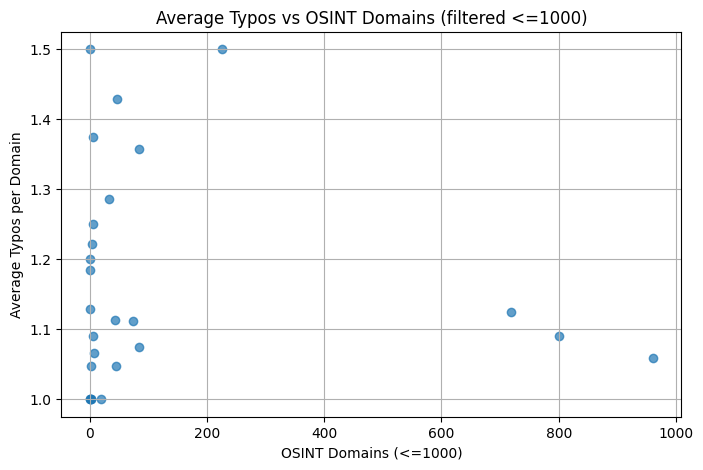

Pearson correlation (avg_typos, osint_domains <=1000): -0.097
Pearson correlation (avg_typos, log(osint_domains+1) <=1000): 0.081

Top OSINT domains (domain, osint, avg_typos) [osint <= 1000]:
google.com: 961, 1.0588235294117647
microsoft.com: 800, 1.0909090909090908
wellsfargo.com: 719, 1.125
bankofamerica.com: 225, 1.5
citizensbank.com: 85, 1.0740740740740742
capitalone.com: 84, 1.3571428571428572


In [14]:
# Average typos vs OSINT domains (exclude osint > 1000)
x_filtered = []
y_filtered = []
domains_filtered = []
for domain, info in company_info.items():
    avg = average_typos.get(domain)
    osint = info.get('osint_domains')
    if avg is None or osint is None:
        continue
    if isinstance(osint, float) and np.isnan(osint):
        continue
    if osint > 1000:
        continue
    x_filtered.append(osint)
    y_filtered.append(avg)
    domains_filtered.append(domain)

print("points (osint <= 1000):", len(x_filtered))

plt.figure(figsize=(8,5))
plt.scatter(x_filtered, y_filtered, alpha=0.7)
plt.xlabel('OSINT Domains (<=1000)')
plt.ylabel('Average Typos per Domain')
plt.title('Average Typos vs OSINT Domains (filtered <=1000)')
plt.grid(True)
plt.show()

if len(x_filtered) > 1:
    corr_avg_osint_1000 = np.corrcoef(x_filtered, y_filtered)[0,1]
    print(f"Pearson correlation (avg_typos, osint_domains <=1000): {corr_avg_osint_1000:.3f}")
    corr_avg_logosint_1000 = np.corrcoef(np.log1p(x_filtered), y_filtered)[0,1]
    print(f"Pearson correlation (avg_typos, log(osint_domains+1) <=1000): {corr_avg_logosint_1000:.3f}")
else:
    print("Not enough points to compute correlation.")

# show top OSINT domains (filtered) for context
top_by_osint_filtered = sorted(zip(domains_filtered, x_filtered, y_filtered), key=lambda t: t[1], reverse=True)[:6]
print("\nTop OSINT domains (domain, osint, avg_typos) [osint <= 1000]:")
for d, ox, ay in top_by_osint_filtered:
    print(f"{d}: {ox}, {ay}")


In [15]:
from collections import defaultdict

# Sum typos by NAICS sector
sector_typos = defaultdict(int)
sector_counts = defaultdict(int)

for domain, info in company_info.items():
    sector = info.get('naics_sector', 'Unknown')
    sector_typos[sector] += typo_counts.get(domain, 0)
    sector_counts[sector] += 1

# Sort and print results
sector_typos_sorted = sorted(sector_typos.items(), key=lambda t: t[1], reverse=True)
print("Sum of typos per NAICS sector (total_typos, domain_count):")
for sector, total in sector_typos_sorted:
    print(f"{sector}: {total}, domains={sector_counts[sector]}")

Sum of typos per NAICS sector (total_typos, domain_count):
Retail Trade: 203, domains=6
Finance and Insurance: 193, domains=9
Utilities: 74, domains=2
Information: 38, domains=4
Professional, Scientific, and Technical Services: 34, domains=1
Manufacturing: 23, domains=3
Transportation and Warehousing: 18, domains=1
Mining, Quarrying, and Oil and Gas Extraction: 8, domains=1


In [16]:
sector_avg_typos = defaultdict(list)
sector_domains = defaultdict(list)

for domain, info in company_info.items():
    sector = info.get('naics_sector', 'Unknown')
    avg = average_typos.get(domain)
    if avg is not None:
        sector_avg_typos[sector].append(avg)
        sector_domains[sector].append(domain)

sector_avg_typos_sorted = sorted(
    sector_avg_typos.items(),
    key=lambda t: np.mean(t[1]) if t[1] else 0,
    reverse=True
)

print("Average typos per NAICS sector (avg_typos, domain_count, domains):")
for sector, avgs in sector_avg_typos_sorted:
    domains = sector_domains.get(sector, [])
    mean = float(np.mean(avgs)) if avgs else 0.0
    print(f"{sector}: {mean:.3f}, domains={len(avgs)}")
    print("  URLs:", ", ".join(domains))

Average typos per NAICS sector (avg_typos, domain_count, domains):
Mining, Quarrying, and Oil and Gas Extraction: 1.375, domains=1
  URLs: halliburton.com
Manufacturing: 1.345, domains=3
  URLs: corning.com, modernatx.com, pfizer.com
Transportation and Warehousing: 1.222, domains=1
  URLs: alaskaair.com
Information: 1.216, domains=4
  URLs: microsoft.com, netflix.com, oracle.com, verizon.com
Finance and Insurance: 1.192, domains=9
  URLs: allstate.com, americanexpress.com, bankofamerica.com, capitalone.com, citizensbank.com, guardianlife.com, libertymutual.com, thehartford.com, wellsfargo.com
Utilities: 1.093, domains=2
  URLs: centerpointenergy.com, dominionenergy.com
Retail Trade: 1.059, domains=6
  URLs: advanceautoparts.com, homedepot.com, kohls.com, target.com, tractorsupply.com, wayfair.com
Professional, Scientific, and Technical Services: 1.059, domains=1
  URLs: google.com


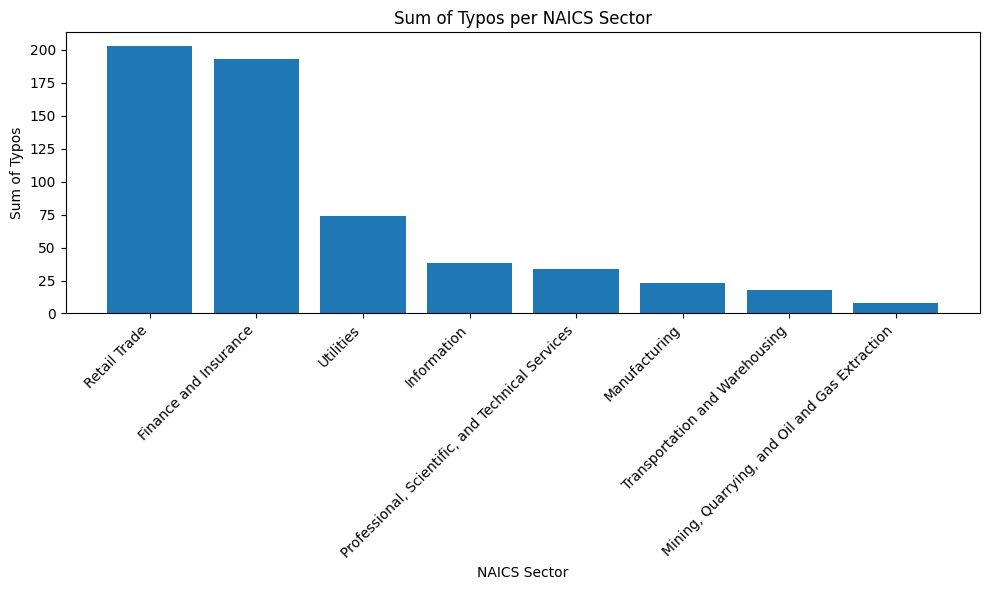

In [17]:
# Bar plot of the sum of typos per NAICS sector (fix extraction from sector_typos_sorted)
sectors = [sector for sector, total in sector_typos_sorted]
sums = [total for sector, total in sector_typos_sorted]

plt.figure(figsize=(10, 6))
plt.bar(sectors, sums)
plt.xlabel('NAICS Sector')
plt.ylabel('Sum of Typos')
plt.title('Sum of Typos per NAICS Sector')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


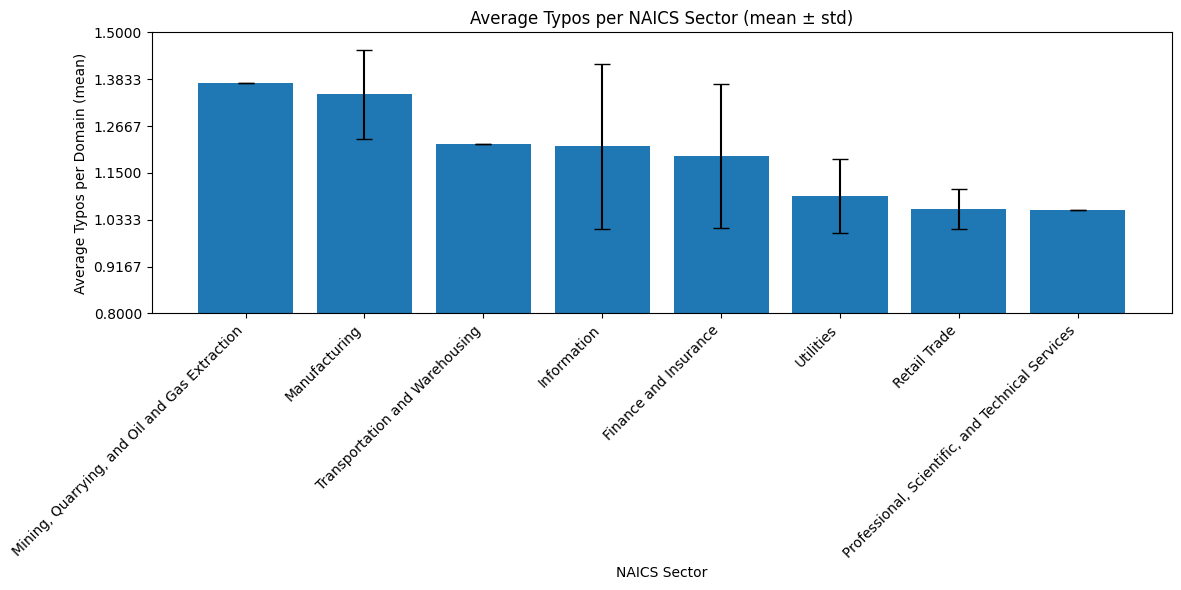

Sector means (mean ± std, n_domains):
Mining, Quarrying, and Oil and Gas Extraction: 1.375 ± 0.000, n=1
Manufacturing: 1.345 ± 0.110, n=3
Transportation and Warehousing: 1.222 ± 0.000, n=1
Information: 1.216 ± 0.205, n=4
Finance and Insurance: 1.192 ± 0.180, n=9
Utilities: 1.093 ± 0.093, n=2
Retail Trade: 1.059 ± 0.050, n=6
Professional, Scientific, and Technical Services: 1.059 ± 0.000, n=1

Overall stats:
Mean average_typos per domain (all domains): 1.179
Mean of sector means (unweighted): 1.195
Weighted mean of sector means (by number of domains in sector): 1.179


In [18]:
# Bar plot of the average typos per NAICS sector (mean ± std) and summary stats

# compute mean/std per sector from existing sector_avg_typos
sector_means = {s: float(np.mean(avgs)) for s, avgs in sector_avg_typos.items()}
sector_stds = {s: float(np.std(avgs)) for s, avgs in sector_avg_typos.items()}
sector_ns = {s: len(avgs) for s, avgs in sector_avg_typos.items()}

# order by mean descending
sectors_ord = sorted(sector_means.keys(), key=lambda s: sector_means[s], reverse=True)
means = [sector_means[s] for s in sectors_ord]
stds = [sector_stds[s] for s in sectors_ord]
ns = [sector_ns[s] for s in sectors_ord]

plt.figure(figsize=(12,6))
plt.bar(sectors_ord, means, yerr=stds, capsize=6)
plt.xlabel('NAICS Sector')
plt.ylabel('Average Typos per Domain (mean)')
plt.title('Average Typos per NAICS Sector (mean ± std)')
plt.xticks(rotation=45, ha='right')

# set y-axis range from 0.8 to 2 as requested
plt.ylim(0.8, 1.5)
plt.yticks(np.linspace(0.8, 1.5, 7))

plt.tight_layout()
plt.show()

# Summary prints
print("Sector means (mean ± std, n_domains):")
for s, m, sd, n in zip(sectors_ord, means, stds, ns):
    print(f"{s}: {m:.3f} ± {sd:.3f}, n={n}")

# overall statistics / "average of the averages" etc
overall_mean_per_domain = float(np.mean(list(average_typos.values())))            # mean across all domains
mean_of_sector_means = float(np.mean(list(sector_means.values())))               # mean of sector means
weighted_sector_mean = float(np.average(list(sector_means.values()),
                                        weights=[sector_counts[s] for s in sector_means.keys()]))  # weighted by domain count per sector

print("\nOverall stats:")
print(f"Mean average_typos per domain (all domains): {overall_mean_per_domain:.3f}")
print(f"Mean of sector means (unweighted): {mean_of_sector_means:.3f}")
print(f"Weighted mean of sector means (by number of domains in sector): {weighted_sector_mean:.3f}")

In [19]:
#print all the typos that have 3 of level
for domain, typos in data.items():
    typos_eq3_list = [typo for typo, count in typos.items() if count == 3]
    if typos_eq3_list:
        print(f"{domain}: {typos_eq3_list}")

centerpointenergy.com: ['denterpointenergy.com']
americanexpress.com: ['americamexpress.com']
bankofamerica.com: ['bankofamerida.com', 'bamkofamerica.com']
homedepot.com: ['honedepot.com']


In [20]:
#print all the typos that have 2 of level
for domain, typos in data.items():
    typos_eq2_list = [typo for typo, count in typos.items() if count == 2]
    if typos_eq2_list:
        print(f"{domain}: {typos_eq2_list}")

microsoft.com: ['microspft.com']
libertymutual.com: ['ilbertymutual.com']
advanceautoparts.com: ['advanecautoparts.com', 'advanceautopart.com', 'advanceautpparts.com', 'advancedautoparts.com', 'advanceautoarts.com']
centerpointenergy.com: ['centrerpointenergy.com', 'centerpointenefgy.com', 'centyerpointenergy.com', 'centeroointenergy.com', 'centefpointenergy.com', 'centerppintenergy.com', 'centerpointyenergy.com', 'centerpointehergy.com']
oracle.com: ['pracle.com']
thehartford.com: ['theharrtford.com', 'wwwthehartford.com']
alaskaair.com: ['alaskaaire.com', 'alasksaair.com', 'alaskaaor.com', 'alasksair.com']
wellsfargo.com: ['wellsfargp.com', 'wellsfarog.com', 'wellzfargo.com', 'swellsfargo.com', 'wellsfarg0.com', 'wellsfarego.com']
citizensbank.com: ['citizensabank.com', 'citizensbahk.com']
americanexpress.com: ['americanexpess.com']
modernatx.com: ['modernastx.com', 'modernatxs.com', 'wwwmodernatx.com', 'modernatz.com']
verizon.com: ['verizom.com']
bankofamerica.com: ['bankifamerica.